In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
data_slim = data[["config_id", "seed", "performance", "last_performance", "env_name", "algorithm", "last_performance_unnormalized"]].copy()
data_slim.head()

,config_id,seed,performance,last_performance,env_name,algorithm,last_performance_unnormalized
0,0,9,4742.1875,0.111053,atari_battle_zone,ppo,3397.65625
1,1,9,6640.6250,0.029107,atari_battle_zone,ppo,1075.00000
2,2,9,2000.0000,0.050772,atari_battle_zone,ppo,1689.06250
3,3,9,1718.7500,0.610281,atari_battle_zone,ppo,17547.65620
4,4,9,0.0000,0.050882,atari_battle_zone,ppo,1692.18750


In [4]:
def per_env_plot(
        plot_data: pd.DataFrame,
        x: str,
        y: str,
        envs: list[str],
        algo_colors: dict[str, str]
    ):
        # Create subplots for each environment
    n_envs = len(envs)
    n_cols = 4
    n_rows = (n_envs + n_cols - 1) // n_cols  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for i, env in enumerate(envs):
        ax = axes[i]
        env_data = plot_data[plot_data["env_name"] == env]
        
        sns.scatterplot(
            data=env_data,
            x=x,
            y=y,
            hue="algorithm",
            palette=algo_colors,
            ax=ax,
            alpha=0.7
        )
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(env)
        ax.legend(title="Algorithm")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()  

## Motivation

A well-behaved algorithm configuration would exhibit a high mean $\bar{x}_{h,m}$ over seeds on a set task, to indicate the average performance of that configuration. However, an algorithm should also exhibit a low variance $\bar{v}_{h,m}$ over seeds, as this is an indicator for the reliability of the performance. 



In [5]:
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=("performance", "mean"),
    std_per_config=("performance", "std")
).reset_index()
config_stats["std_per_config"] = config_stats["std_per_config"].fillna(0.001)
config_stats.head()

,env_name,algorithm,config_id,mean_per_config,std_per_config
0,atari_battle_zone,dqn,0,1510.15625,1203.691180
1,atari_battle_zone,dqn,1,3125.78125,2490.373763
2,atari_battle_zone,dqn,2,1571.09375,2157.633429
3,atari_battle_zone,dqn,3,3467.18750,1795.597372
4,atari_battle_zone,dqn,4,2304.68750,1502.071623


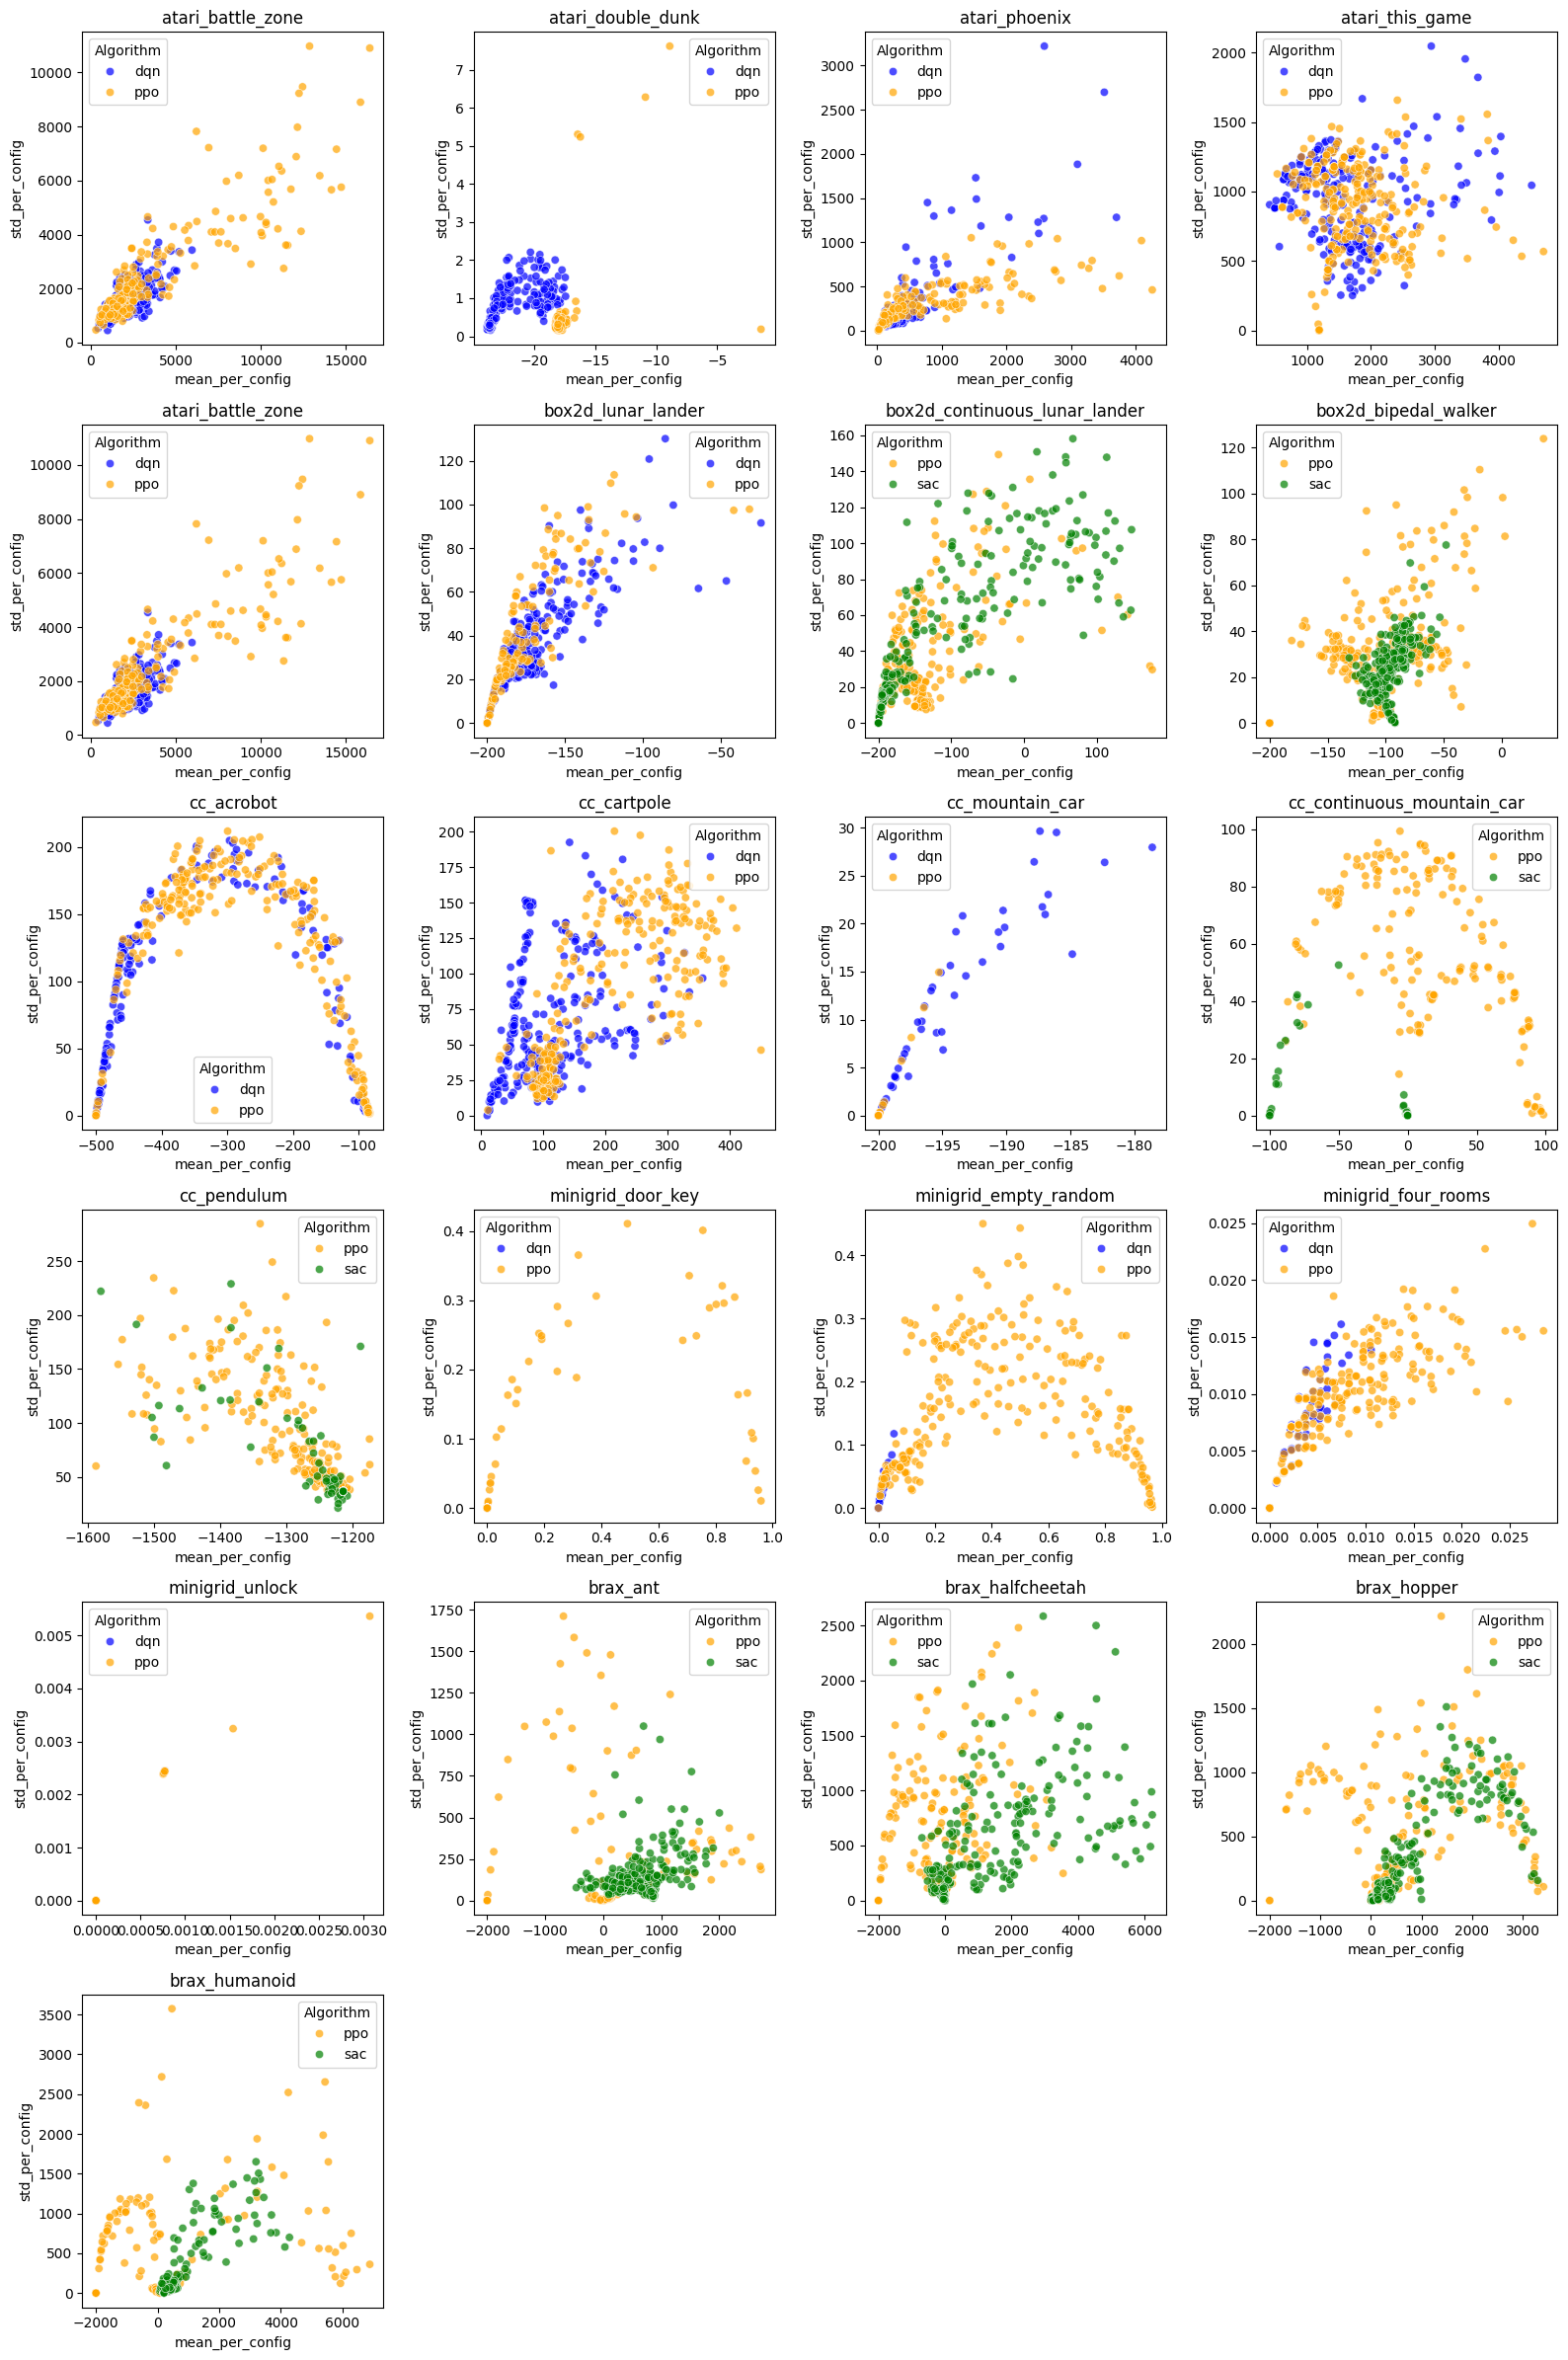

In [6]:
# Define color palette
algo_colors = {"sac": "green", "ppo": "orange", "dqn": "blue"}

per_env_plot(
    plot_data=config_stats,
    x="mean_per_config",
    y="std_per_config",
    envs=envs,
    algo_colors=algo_colors
)

Looking at this, we seem to have two kinds of results:

In the first case, we have a "rainbow" shape, where at points where the mean performance reaches a maximum, the variance also vanishes -- this is the kind of behaviour that would be desired: robust and strong performance.

In contrast, on other tasks, we "pay" for high performance with higher variance, which results in higher variability across seeds; and renders results even more dependent on the seed selection

To put this into a number, we first draw inspiration from optimisation under risk and look at the Sharpe ratio:

$$ S = \frac{\bar{x}_{m,h} - \bar{x}}{\sqrt{\bar{v}_{m,h}}} $$

where $\bar{x}$ is some pre-defined baseline

In [7]:
config_stats["mean_per_alg"] = config_stats.groupby(["env_name", "algorithm"])["mean_per_config"].transform("mean")
config_stats["Sharpe_ratio"] = (config_stats["mean_per_config"] - config_stats["mean_per_alg"]) / config_stats["std_per_config"]

config_stats.head()

,env_name,algorithm,config_id,mean_per_config,std_per_config,mean_per_alg,Sharpe_ratio
0,atari_battle_zone,dqn,0,1510.15625,1203.691180,2199.246216,-0.572481
1,atari_battle_zone,dqn,1,3125.78125,2490.373763,2199.246216,0.372047
2,atari_battle_zone,dqn,2,1571.09375,2157.633429,2199.246216,-0.291130
3,atari_battle_zone,dqn,3,3467.18750,1795.597372,2199.246216,0.706139
4,atari_battle_zone,dqn,4,2304.68750,1502.071623,2199.246216,0.070197


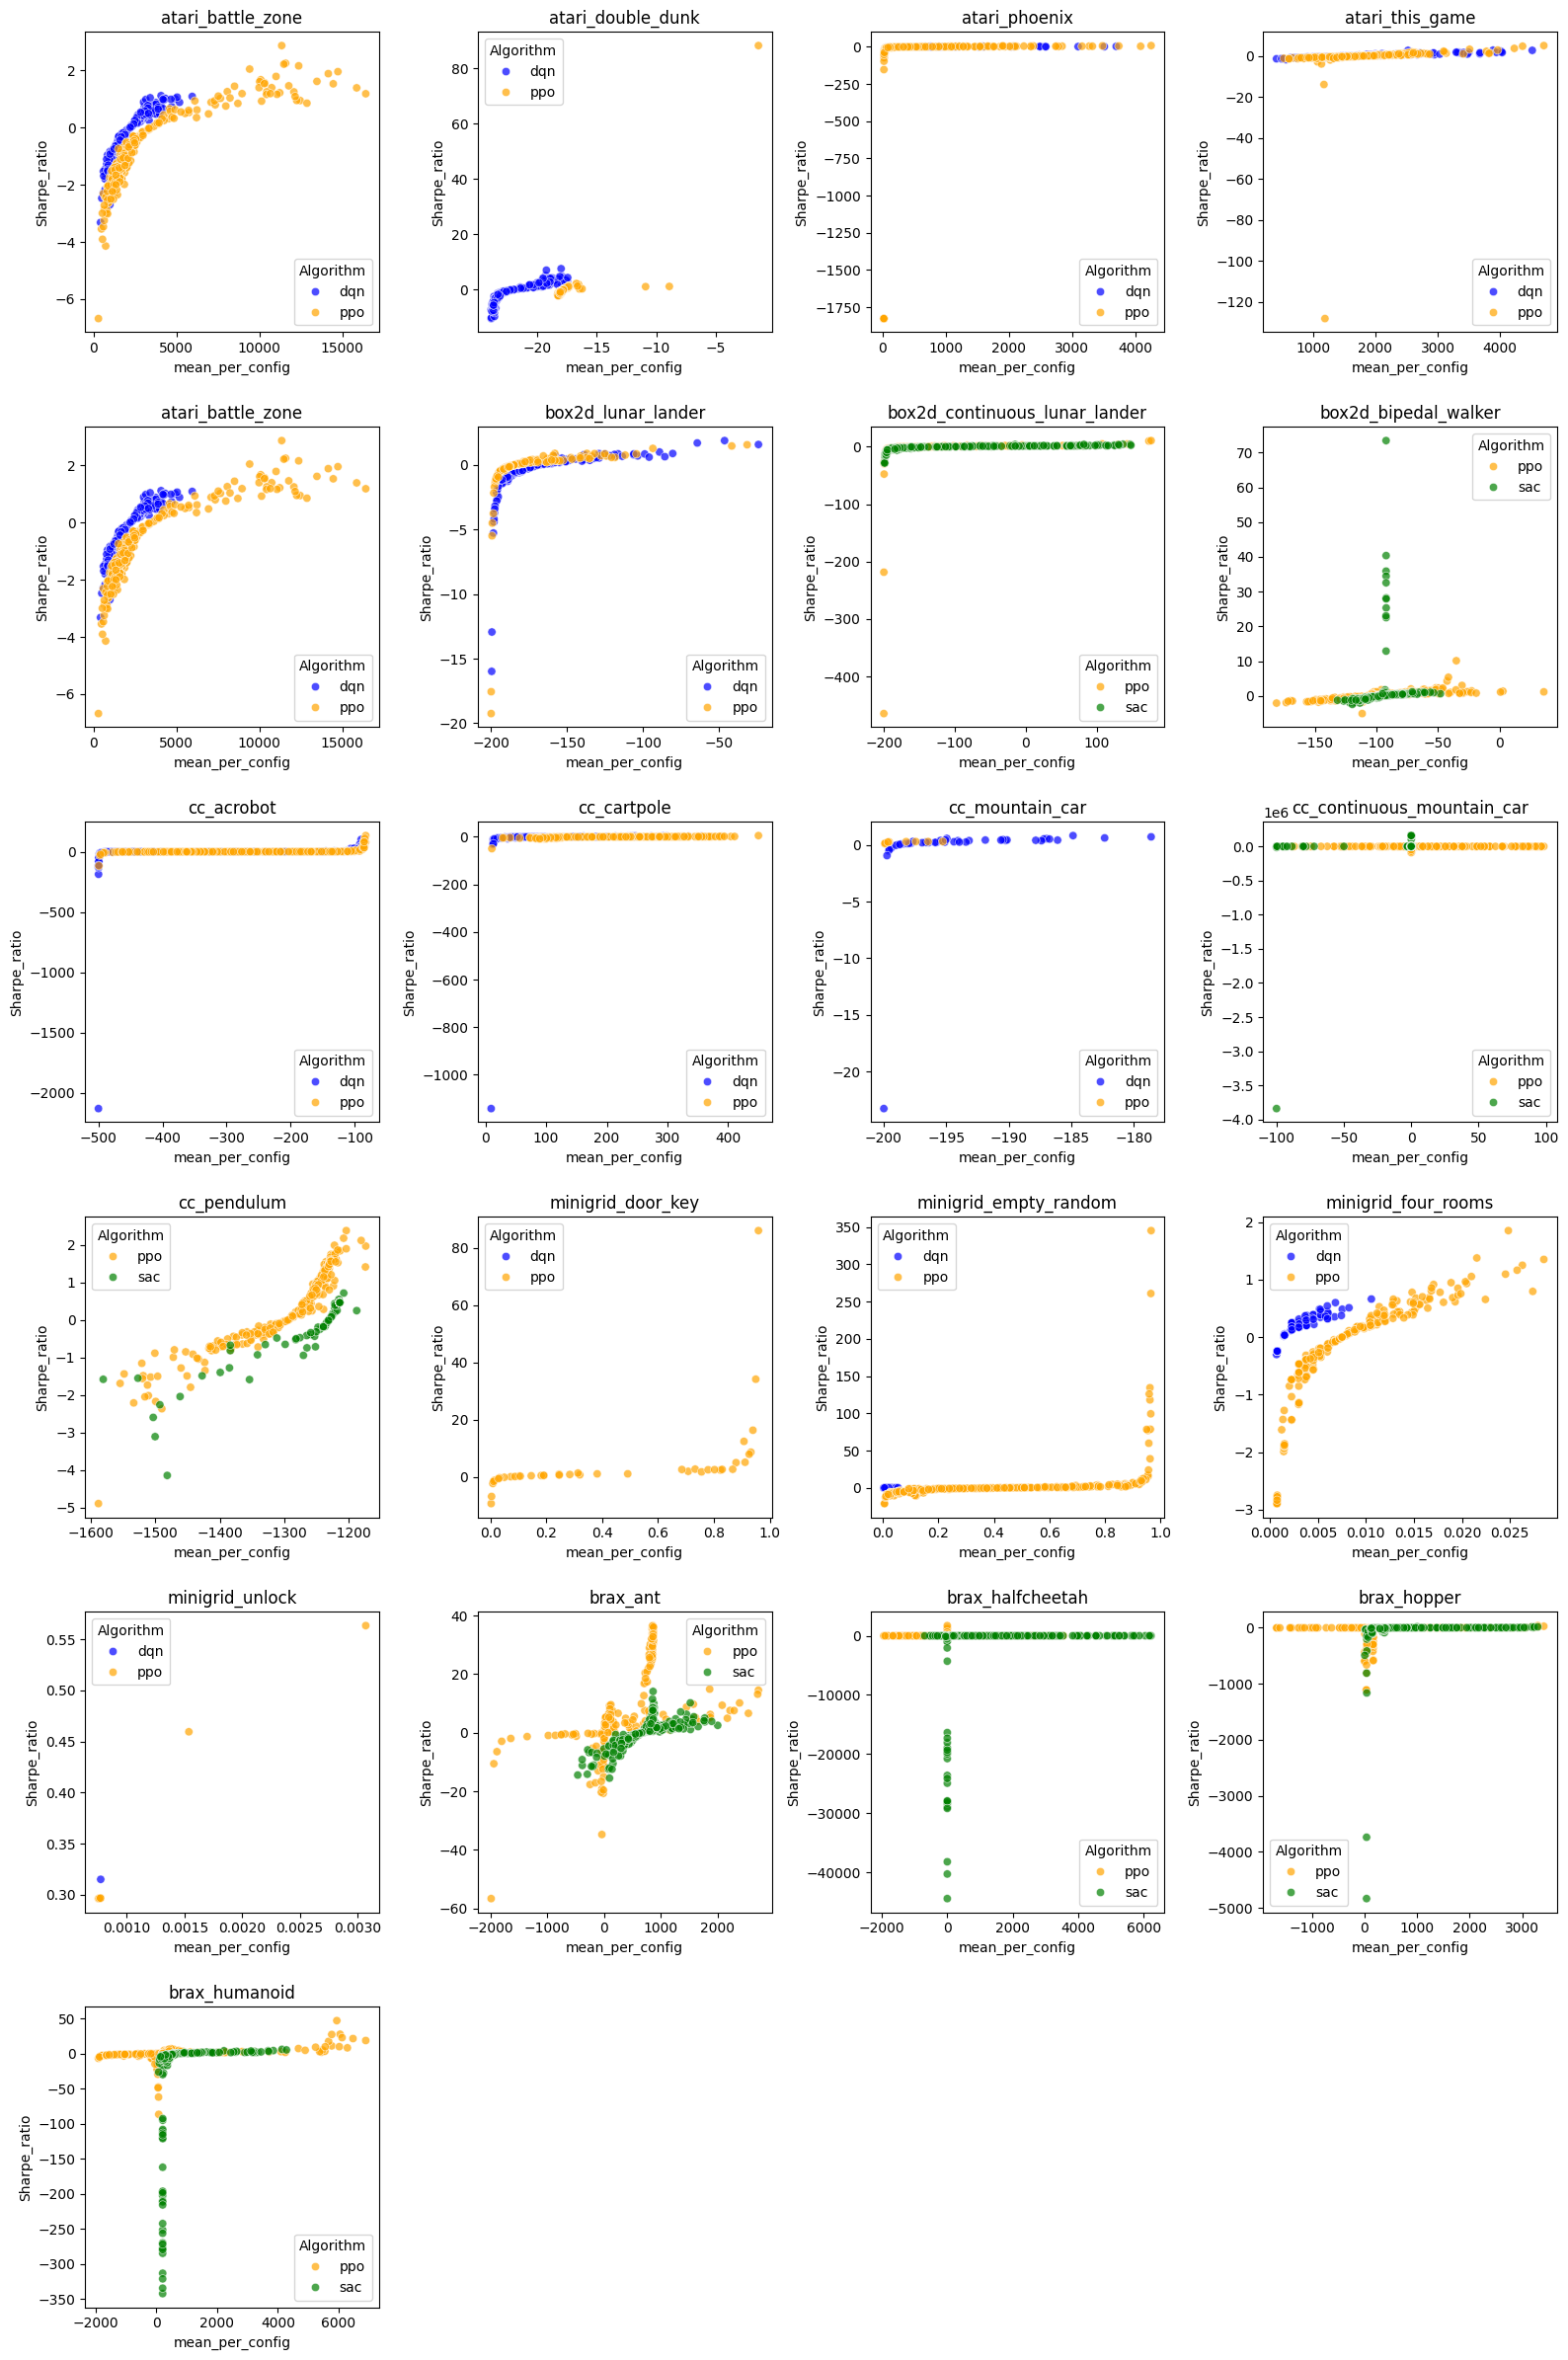

In [8]:
per_env_plot(
    plot_data=config_stats,
    x="mean_per_config",
    y="Sharpe_ratio",
    envs=envs,
    algo_colors=algo_colors
)


Alternatively: Confidence lower bound

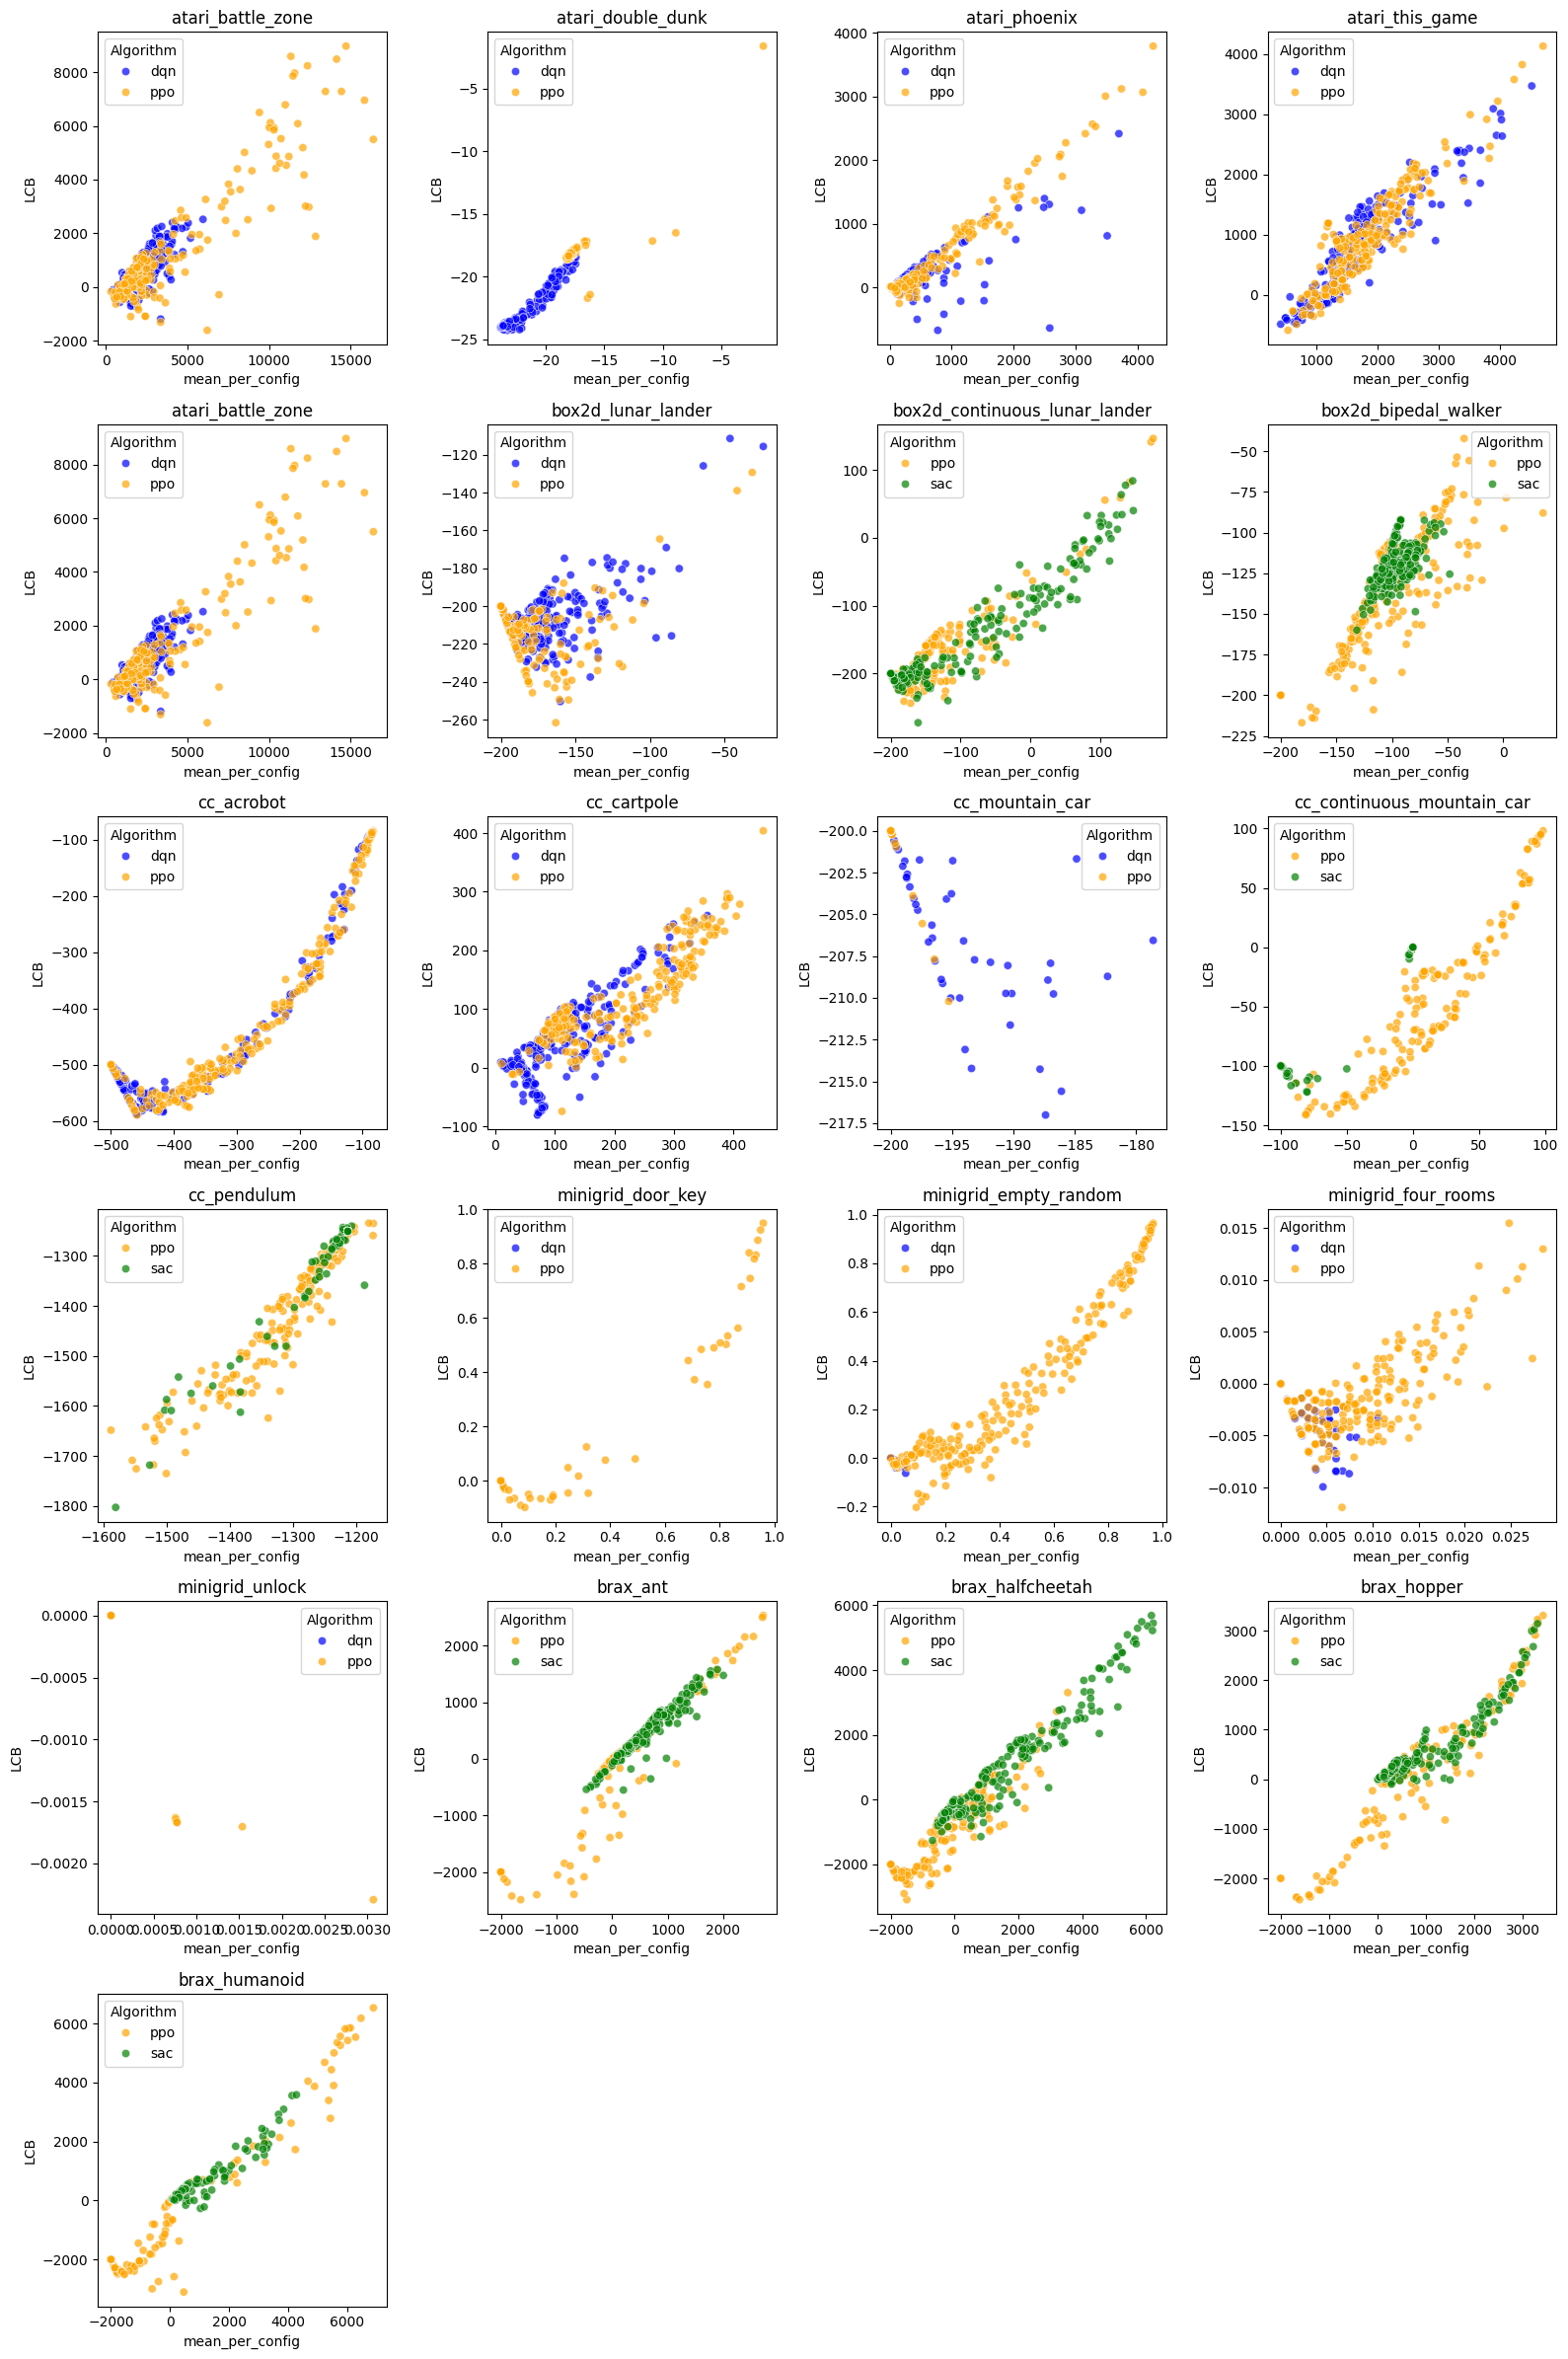

In [9]:
config_stats["LCB"] = config_stats["mean_per_config"] - config_stats["std_per_config"]

per_env_plot(
    plot_data=config_stats,
    x="mean_per_config",
    y="LCB",
    envs=envs,
    algo_colors=algo_colors
)

maybe, after all, the config mean is good enough as a descriptor; it appears that by maximising the mean over seeds, we also maximise the lower confidence bound

In [13]:
try:
    envs.remove("cc_mountain_car")
except:
    pass

In [14]:
def per_env_plot_new(
        plot_data: pd.DataFrame,
        x: str,
        y1: str,
        y2: str,
        y3: str,
        envs: list[str],
        algo_colors: dict[str, str]
    ):
        # Create subplots for each environment
    n_envs = len(envs)
    n_cols = 3
    n_rows = n_envs

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for i, env in enumerate(envs):
        
        env_data = plot_data[plot_data["env_name"] == env]

        for j, y in enumerate([y1, y2, y3]):
            ax = axes[i * 3 + j]
        
            sns.scatterplot(
                data=env_data,
                x=x,
                y=y,
                hue="algorithm",
                palette=algo_colors,
                ax=ax,
                alpha=0.7
            )
       
            ax.set_xlabel(x)
            ax.set_ylabel(y)
            ax.set_title(env)
            ax.legend(title="Algorithm")

    # Hide unused subplots
    # for j in range(i + 1, len(axes)):
    #     axes[j].set_visible(False)

    plt.tight_layout()  

In [ ]:
envs

In [15]:
per_env_plot_new(
    plot_data=config_stats,
    x="mean_per_config",
    y2="Sharpe_ratio",
    y3="LCB",
    y1="std_per_config",
    envs=envs,
    algo_colors=algo_colors
)

TypeError: object of type 'NoneType' has no len()